# Практикум по программированию на языке Python

## <font color='lilac'>Занятие 7: Основы работы с искусственными нейронными сетями</font>

#### Мурат Апишев (mel-lain@yandex.ru)
#### Москва, 2025

In [76]:
import warnings
warnings.filterwarnings('ignore')

### <font color='lilac'>Почему нейросети</font>

- Универсальная аппроксимация функций:

_Искусственная нейронная сеть прямой связи с одним скрытым слоем может аппроксимировать любую непрерывную функцию многих переменных с любой точностью при достаточном количестве нейронов в скрытом слое и правильном подборе весов_

- Удобное конструирование сложных моделей
- Гибкость в создании новых архитектур
- Эффективность в задачах transfer learning

- Доминирование в мире ML в последние 12 лет:
    - разнообразные и развитые библиотеки для обучения
    - множество архитектур сетей и слоёв для разных задач и данных
    - развитые методы оптимизации
    - эффективные фреймворки для распределённого обучения
    - огромный опыт обучения моделей со всевозможными конфигурациями
    - решение широкого круга задач, включая создание ИИ-подобных систем

- Базовые условия, позволившие совершить этот прорыв:
    - огромный объём накопленных в мире данных
    - наличие игровых графических ускорителей для векторной линейной алгебры
    - метод обратного распространения ошибки

### <font color='lilac'>Инструменты для обучения нейросетей</font>

- Написать и обучить нейронную сеть можно самостоятельно с помощью NumPy (попробуем ниже)
- Но разумнее использовать готовые библиотеки, наиболее популярные сейчас:
    - PyTorch
    - TensorFlow (+ Keras)
    - JAX
- Список не ограничивается только этими инструментами, некоторые устарели, например, Theano

### <font color='lilac'>Библиотека PyTorch</font>

- В большинстве компаний используется именно PyTorch:
    - удобный интерфейс и простой синтаксис на Python
    - динамический граф вычислений (построение при выполнении) позволяет гибко контролировать каждый этап обучения модели
    - модели для ускорения инференса можно конвертировать в статические графы (построение до запуска) и оптимизировать
    - эффективная поддержка и CPU, и GPU, распределение нагрузки между ними
    - богатая библиотека модулей, инструментов и алгоритмов
    - большая экосистема open-source решений, индустриальный стандарт
- Подходящую актуальную команду для установки можно найти на [официальном сайте](https://pytorch.org/get-started/locally)

### <font color='lilac'>Backpropogation</font>

- Backprop - метод обратного распространения ошибки - универсальный алгоритм для обучения любых нейронных сетей
- Хорошая [статья](https://education.yandex.ru/handbook/ml/article/metod-obratnogo-rasprostraneniya-oshibki) для разбора теории

- __Интуиция:__
    - для обучения сети нужно уметь считать градиенты на каждом её слое, чтобы сдвигать веса в направлении уменьшения эмпирической ошибки
    - нейросеть - это сложная функция входа модели
    - производная сложной функции по входу - это произведение всех последовательных частных производных
    - можно вычислить их все и получить целевую производную функции потерь по входу

- __Основная идея:__
    - каждый слой - это новая функция внутри общей сложной функции, которую представляет собой нейросеть
    - зная градиент функции потерь на последнем слое, можно посчитать градиент на предпоследнем и так далее до первого
    - считать градиенты явным дифференцированием в общем виде дорого и по памяти, и по времени
    - вместо этого для вычисления градиента следующего слоя по текущему используется умножение на некоторое отображение:
$$f(x) = g(h(x)) \quad\Rightarrow\quad {\color{green}\nabla_{x_0}f} = {\color{red}[D_{x_0} h]^*} \cdot {\color{blue}\nabla_{h_{x_0}}g}$$
    - это позволяет вычислять градиенты для каждого слоя независимо от других и изолировать слои друг от друга

- __Схема работы:__
    - проход вперёд (forward):
        - модели даётся на вход набор объектов (batch), он проходит через все слои для получения предсказания
        - в базовом варианте все выходы каждого слоя (активации) кэшируются
    - по предсказанию считается ошибка
    - проход назад (backward):
        - на основе ошибки считается градиент на последнем слое
        - начиная с него градиенты считаются слой за слоем до первого
        - в процессе используются кэшированные активации
        - градиенты сохраняются
    - обновление весов оптимизатором на основе градиентов (для гибкости и оптимизации отдельно от шага backward)

- Каждый слой - отдельный модуль, который можно разрабатывать и встраивать независимо от других
- Он минимально должен иметь две функциональности:
    - проход вперёд для основного вычисления
    - соответствующий проход назад для получения градиентов

### <font color='lilac'>Полносвязная нейронная сеть</font>

- Ключевым компонентом практически любой нейросети являются полносвязные (линейные) слои
- Базовая нейросетевая архитектура - набор линейных слоёв разных размеров с нелинейными функциями активации между ними
- Каждый слой генерирует новое промежуточное векторное представление объекта
- На последнем слое обычно генерируется ответ модели (хотя результатом может быть и вектор итогового представления)

<img style="width: 600px;" src="https://www.ibm.com/content/dam/connectedassets-adobe-cms/worldwide-content/cdp/cf/ul/g/3a/b8/ICLH_Diagram_Batch_01_03-DeepNeuralNetwork.png">

- Параметрами линейного слоя явлются матрица весов (weight) и вектор сдвигов (bias), для простоты нотации он может опускаться в выкладках
- Веса состоят из $M$ векторов размерности $N$
    - $N$ - размерность вектора входного объекта
    - $M$ - число нейронов == размерность выходного вектора для объекта
- На картинке выше кружки - это векторы (т.е. входы и выходы), слои (т.е. веса) - это стрелки между ними

### <font color='lilac'>Методы оптимизации</font>

- Нейросети обучаются различными вариациями градиентного спуска:

$$w := w - \eta \nabla f(x)$$

- Для реальных моделей обучение обычно стохастическое - обновление весов производится после обработки случайного набора объектов, а не всех
- Примеры классических популярных алгоритмов:
    - SGD
    - Momentum
    - Adagrad
    - RMSProp
    - AdamW
- Методы второго порядка малоприменимы из-за невозможности использования стохастического обучения

### <font color='lilac'>Нейросетевой линейный классификатор</font>
- В простейшем случае сеть может состоять из одного слоя, который переводит входной вектор признаков в одно число - это линейная модель
- Есть добавить на выходе сигмоидальную функцию активации, получится лог-регрессия
- Создадим свою реализацию такой нейросети и обучим её с помощью numpy (основано на коде из [этой статьи](https://www.kaggle.com/code/mtax687/l-layer-neural-network-using-numpy))

- Нужно описать
    - линейный слой
    - слой активации
    - модель, соединяющую их
    - подсчёт функции потерь
    - обновление весов
    - цикл обучения

- Лог-лосс для бинарного классификатора:

$$-\cfrac{1}{m} \sum_{i=1}^m\bigg( y_i \log a_i + (1 - y_i) \log(1 - a_i) \bigg)$$

- Формулы для forward-шага очевидные:
$$z = Wx + b$$
$$a = g(z) = \cfrac{1}{1 + \exp(-z)}$$

- Формулы для backward-шага менее очевидные (с выводом желательно разобраться самостоятельно)
- В соответствии с методом, нужно посчитать для батча размера $m$
    - градиент $da$ на основе функции потерь:
$$da = \cfrac{\partial \mathcal{L}}{\partial a} = -\bigg( \cfrac{y}{a} - \cfrac{1 - y}{1 - a} \bigg)$$
    - градиенты $dz$ на основе $da$:
$$dz = \cfrac{\partial \mathcal{L}}{\partial z} = da \odot g'(z) = da \odot g(z) \odot (1 - g(z))$$
    - градиенты $dW$, $db$ на основе $dz$:
$$dW = \cfrac{\partial \mathcal{L}}{\partial W} = \cfrac{1}{m} dz \cdot x^T$$
$$db = \cfrac{\partial \mathcal{L}}{\partial b} = \cfrac{1}{m} \sum_{i=1}^m dz_i$$

### <font color='lilac'>Слои и модель</font>

In [2]:
import numpy as np
np.random.seed(42)

In [3]:
class Linear:
    def __init__(self, input_dim, output_dim):
        # define and initialize parameters (important not to have to big weights!)
        self.W = np.random.randn(input_dim, output_dim) / np.sqrt(input_dim + output_dim)
        self.b = np.zeros((output_dim, 1))

        # cache to store data for further backward pass
        self.cache = None

    # x.shape = (batch_size, input_dim)
    def forward(self, x):
        self.cache = x
        z = x @ self.W + self.b

        return z

    # dz.shape = (batch_size, output_dim)
    def backward(self, dz):
        x = self.cache

        batch_size = x.shape[0]

        dW = (1.0 / batch_size) * x.T @ dz
        db = (1.0 / batch_size) * np.sum(dz, axis=0, keepdims=True)

        return dW, db

In [4]:
class Sigmoid:
    def __init__(self):
        self.cache = None

    # z.shape = (batch_size, output_dim)
    def forward(self, z):
        a = 1. / (1. + np.exp(-z))
        self.cache = a

        return a

    # da.shape = (batch_size, output_dim)
    def backward(self, da):
        a = self.cache
        dz = da * a * (1 - a)

        return dz

In [5]:
class Model:
    def __init__(self, input_dim, output_dim):
        self.linear = Linear(input_dim, output_dim)
        self.activation = Sigmoid()

    def forward(self, x):
        z = self.linear.forward(x)
        a = self.activation.forward(z)

        return a

    def backward(self, da):
        dz = self.activation.backward(da)
        dW, db = self.linear.backward(dz)

        return dW, db

### <font color='lilac'>Подсчёт ошибки и обновление весов</font>

In [6]:
def compute_loss(a, y):   
    batch_size = y.shape[0]
    loss = (-1. / batch_size) * (y.T @ np.log(a) + (1 - y).T @ np.log(1 - a)).squeeze() # [[x]] -> x
    da = - (np.divide(y, a) - np.divide(1 - y, 1 - a))
    return loss, da

In [7]:
def optimization_step(model, gradients, learning_rate):
    dW, db = gradients

    model.linear.W -= learning_rate * dW
    model.linear.b -= learning_rate * db

### <font color='lilac'>Загрузка данных</font>

- Нормализация данных крайне важна - самописная модель не будет работать из-за больших чисел и разности масштаба признаков

In [8]:
import kagglehub
import pandas as pd

from pathlib import Path
from sklearn.model_selection import train_test_split

data_path = kagglehub.dataset_download("gauravduttakiit/reservation-cancellation-prediction")

data = pd.read_csv(Path(data_path) / 'train__dataset.csv')
data, labels = data[data.columns[: -1]].to_numpy(), data[data.columns[-1]].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.5)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [10]:
y_train = y_train.reshape(y_train.shape[0], 1)
y_test = y_test.reshape(y_test.shape[0], 1)

### <font color='lilac'>Цикл обучения</font>

- Для наглядности модель обучается с помощью обычного градиентного спуска (без SGD и батчей)
- Из-за этого темп обучения будет очень большой для ускорения сходимости (в SGD значения обычно 0.01-0.05)
- Обычно в цикле обучения два уровня - уровень эпохи (проход по всем данным) и уровень батча, в примере второго нет

In [11]:
from sklearn.metrics import roc_auc_score

num_features = x_train.shape[1]
num_epochs = 20
learning_rate = 0.5

In [12]:
train_loss_list, test_loss_list = [], []
test_auc_list = []

# create neural network model
model = Model(num_features, 1)

# one epoch - one pass over all data
for _ in range(num_epochs):

    # run model to get predictions
    a = model.forward(x_train)

    # compute loss and gradients for activation layer
    loss, da = compute_loss(a, y_train)

    # get gradients of parameters during backward pass
    gradients = model.backward(da)

    # update model parameters
    optimization_step(model, gradients, learning_rate=learning_rate)

    train_loss_list.append(loss)

    # test model on this epoch    
    a = model.forward(x_test)
    loss, _ = compute_loss(a, y_test)

    test_loss_list.append(loss)
    test_auc_list.append(roc_auc_score(y_test, a))

### <font color='lilac'>Визуализация результатов</font>

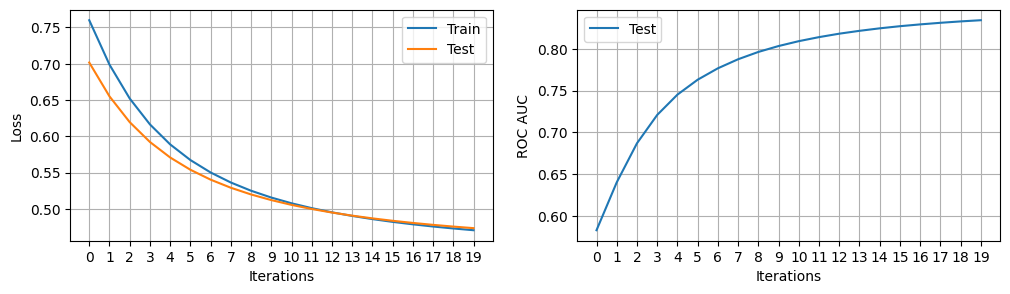

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), train_loss_list)
plt.plot(range(num_epochs), test_loss_list)
plt.legend(["Train", "Test"])
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.xticks(range(20))
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), test_auc_list)
plt.legend(["Test"])
plt.xlabel("Iterations")
plt.ylabel("ROC AUC")
plt.xticks(range(20))
plt.grid()

plt.show()

### <font color='lilac'>Модель в PyTorch</font>

- Ключевой механизм - Autograd: нет необходимости описывать backward-шаг, если forward состоит из стандартных функций или их композиций
- Autograd сам посчитает все градиенты на основе описания forward-шага ([детали работы](https://pytorch.org/docs/stable/notes/autograd.html))
- В остальном все достаточно похоже
- Описание модели с помощью стандартных слоёв из библиотеки:

In [14]:
import torch
import torch.nn as nn

In [15]:
class Model(nn.Module):
    def __init__(self, input_dim, output_dim):
        # don't forget to run parent __init
        super(Model, self).__init__()

        self.linear = nn.Linear(in_features=input_dim, out_features=output_dim, dtype=torch.float32)
        self.activation = nn.Sigmoid()

    def forward(self, x):
        return self.activation(self.linear(x))

### <font color='lilac'>Dataset и Dataloader</font>

- Код подготовки данных тот же:

In [16]:
data = pd.read_csv(Path(data_path) / 'train__dataset.csv')
data, labels = data[data.columns[: -1]].to_numpy(), data[data.columns[-1]].to_numpy()

x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.5)

- Для обучения в PyTorch нормализация уже не так критична, но хуже точно не сделает:

In [17]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

- `torch.utils.data.Dataset` - отвечает за предобработку и доступ к отдельным объектам датасета
- Для своего набора данных нужно описать класс-наследник, который должен определять методы `__len__` и `__getitem__`

In [18]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, data, labels):
        assert len(data) == len(labels)
        self.data = torch.Tensor(data).to(torch.float32)
        self.labels = torch.Tensor(labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [19]:
train_dataset = Dataset(x_train, y_train)
test_dataset = Dataset(x_test, y_test)

- `torch.utils.data.DataLoader` - вытаскивает объекты в соответствии со своей настройкой, собирает из них батчи и возвращает
- Удобный инструмент для итерирования по батчам в цикле обучения при использовании стохастических методов оптимизации
- Размер батча определяет скорость обучения, если обновление идет после каждого батча - то и стабильность
- Обычно выбирается так, чтобы максимально утилизировать ресурсы
- Для простоты кода примера тестовый набор прогоняется целиком, хотя обычно тоже батчами
- Для инференса модели нужно меньше памяти, чем для обучения, и батч на тесте может быть больше, чем на обучении

In [20]:
train_dataloader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
test_dataloader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=10000) # use smaller value in real training

### <font color='lilac'>Модель, оптимизатор, функция потерь</font>

- Модель создаётся аналогично:

In [21]:
num_features = train_dataset.data.shape[1]
model = Model(input_dim=num_features, output_dim=1)

- Важный шаг - выбор и создание оптимизатора
- Оптимизатор берёт контроль за обновленим параметров модели на себя, для этого ему нужно передать их явным образом
- Части параметров сложной модели при необходимости можно обучать своими оптимизаторами

In [22]:
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.05)
# optimizer = torch.optim.AdamW(params=model.parameters(), betas=(0.9, 0.98))

- Отдельно заводится функция потерь, которая будет считать ошибку и градиенты по ней
- В данном случае это та же сигмоида:

In [23]:
loss_fn = torch.nn.BCELoss(reduction='mean')

### <font color='lilac'>Цикл обучения</font>

- Цикл обучения во многом схож с описанным выше, но есть важные детали:
    - оптимизатор накапливает градиенты, их нужно в явном виде обнулять после каждого обновления весов
    - функция потерь возвращает тензор, который является вершиной вычислительного графа - с него начинается шаг backward
    - по этой причине для сохранения значения этого тензора нужно сделать вызов `.item()` и отсоединить его от графа
    - обновление весов, для которых вычисляются градиенты, выполняется вызовом `.step()` оптимизатора

- Модель может находиться в двух режимах - обучения и инференса
- Это влияет на работу некоторых слоев
- Градиенты вычисляются в любом случае - для их отключения используется контекстный менеджер `torch.no_grad()`
- Это всегда стоит делать при инференсе (например, при оценке качества на тесте) - сильно падает потребление времени и памяти

In [24]:
num_epochs = 20

train_loss_list, test_loss_list = [], []
test_auc_list = []

for _ in range(num_epochs):
    # change work of corresponding layers (like BatchNorm or Dropout) into train mode
    model.train()

    running_loss = 0.0

    for i, data in enumerate(train_dataloader):
        inputs, labels = data

        # zero gradients for every batch
        optimizer.zero_grad()

        outputs = model(inputs)

        # compute the loss
        loss = loss_fn(outputs.squeeze(), labels)

        # compute the gradients
        loss.backward()

        # change learnable weights
        optimizer.step()

        # gather data and report (the return value is not differentiable)
        running_loss += loss.item()

    # stop calculating and managing gradients
    with torch.no_grad():
        inputs, labels = test_dataloader.dataset.data, test_dataloader.dataset.labels

        # change work of corresponding layers into eval mode
        model.eval()

        outputs = model(inputs)

        # compute the loss
        test_loss = loss_fn(outputs.squeeze(), labels).item()

    train_loss_list.append(running_loss / (i + 1))
    test_loss_list.append(test_loss)
    test_auc_list.append(roc_auc_score(labels.squeeze(), outputs.squeeze()))

- Результаты получается очень близкие к тем, что получены на самописной модели:

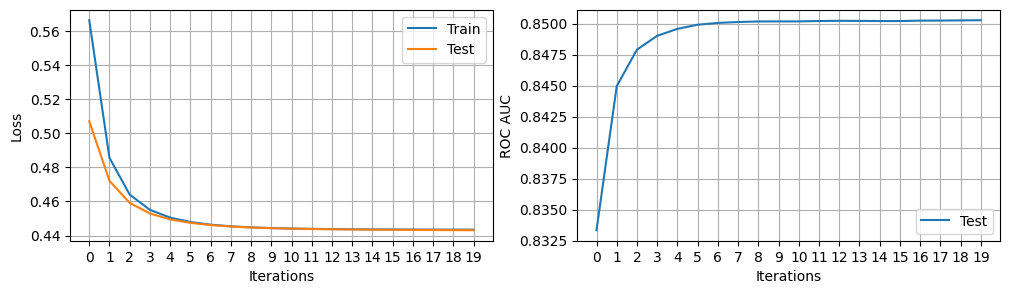

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), train_loss_list)
plt.plot(range(num_epochs), test_loss_list)
plt.legend(["Train", "Test"])
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.xticks(range(20))
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), test_auc_list)
plt.legend(["Test"])
plt.xlabel("Iterations")
plt.ylabel("ROC AUC")
plt.xticks(range(20))
plt.grid()

plt.show()

### <font color='lilac'>Вычислитель для обучения</font>

- Обучение нейросетевых моделей, как и задачи компьютерной графике, основаны на матричных операциях линейной алгебры
- И то, и другое намного эффективнее выполнять на графических ускорителях (GPU)
- Модели выше использовали при обучении CPU
- Правильно описывать код моделей и обучения так, чтобы устройство можно было легко менять (CPU на GPU, или GPU 1 на GPU 2)

- Самый простой и быстрый способ оценить состояние GPU от NVIDIA на локальной машине - утилита `nvidia-smi`:

In [26]:
!nvidia-smi

Wed Mar 19 15:01:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1050        Off |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P8             N/A / ERR!  |       6MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### <font color='lilac'>Обновление кода для обучения на GPU</font>

- нужно отправить на устройство все, что там будет использоваться при вычислениях - параметры и данные

In [27]:
device = torch.device('cuda:0')

In [28]:
# move parameters to device
model = Model(input_dim=num_features, output_dim=1).to(device)

In [29]:
# no changes
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.05)
loss_fn = torch.nn.BCELoss(reduction='mean')

In [30]:
num_epochs = 20

train_loss_list, test_loss_list = [], []
test_auc_list = []

for _ in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, data in enumerate(train_dataloader):
        inputs, labels = data

        # move data to device
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    with torch.no_grad():
        # move data to device
        inputs, labels = test_dataloader.dataset.data.to(device), test_dataloader.dataset.labels.to(device)
        model.eval()

        outputs = model(inputs)
        test_loss = loss_fn(outputs.squeeze(), labels).item()

    train_loss_list.append(running_loss / (i + 1))
    test_loss_list.append(test_loss)
    test_auc_list.append(roc_auc_score(labels.cpu().squeeze(), outputs.cpu().squeeze()))

In [31]:
# GPU memory usage has increased
!nvidia-smi

Wed Mar 19 15:01:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1050        Off |   00000000:01:00.0 Off |                  N/A |
| N/A   43C    P0             N/A / ERR!  |      92MiB /   4096MiB |      4%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### <font color='lilac'>Архитектура Transformer</font>

- Развитие идеи механизма внимания из рекурентных нейросетей (RNN) для задач преобразования последовательности (seq2seq)
- Получает на вход последовательность векторов-представлений элементов (слов, кусочков изображений, фрагментов аудио)
- На выходе в зависимости от модели
    - обновленные векторы для каждого элемента последовательности
    - генерация новых элементов из словаря модели

<img style="width: 600px;" src="https://deeprevision.github.io/posts/001-transformer/transformer.png">

- Основные компоненты:
    - векторные представления входных и выходных элементов из словаря модели
    - позиционное кодирование (при параллельной обработке элементов важно понимать их позицию, абсолютную или относительную)
    - блоки self-attention (для каждого элемента определяют, какие другие элементы входа больше всего влияют на него)
    - блоки полносвязных слоёв (содержат основную информацию о знаниях модели для решения задач обучения)
    - residual connections (пробросы входов мимо блоков для борьбы с затуханием градиентов)
    - слои нормировки (для повышения стабильности и скорости обучения)

- Transformer - основная архитектура современного DL, основа для LLM и ИИ-подобных систем
- Максимально развил идею transfer learning, в том числе в zero-shot / few-shot режимах без дообучения
- Обычно используются в двух вариациях (в соответствии с выходами):
    - BERT-like модели для векторизации и дискриминативных задач (относительно небольшие)
    - LLM для генеративных задач (могут быть гигантскими)

### <font color='lilac'>BERT для задачи поиска близких текстов</font>

- Ранее мы решали задачу поиска близкого текста с помощью TF-IDF + SVD и kNN-индекса
- Заменим векторизатор на небольшую предобученную модель Transformer
- Цель: искать не только по совпадениям слов, но и по близости смысла

- Есть очень много готовых открытых моделей, предобученных на разные задачи в разных доменах и на разных языках
- Основной репозиторий для них - [HuggingFace](https://huggingface.co/models)
- Каждая модель минимально включает в себя веса, конфиг и обученный токенизатор
- Эта же компания поддерживает библиотеку `transformers` - ключевой инструмент для работы с такими моделями, содержащий основной код моделей
- Используем модель `cointegrated/rubert-tiny2`, сперва загрузка модели и токенизатора:

In [ ]:
# pip3 install transformers sentencepiece

from transformers import AutoTokenizer, AutoModel
model_name = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).cuda()  # one more way to send model to single GPU

### <font color='lilac'>Архитектура модели</font>

- Можно вывести архитектуру модели и уточнить интересующие детали:

In [34]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(83828, 312, padding_idx=0)
    (position_embeddings): Embedding(2048, 312)
    (token_type_embeddings): Embedding(2, 312)
    (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-2): 3 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=312, out_features=312, bias=True)
            (key): Linear(in_features=312, out_features=312, bias=True)
            (value): Linear(in_features=312, out_features=312, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=312, out_features=312, bias=True)
            (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)

### <font color='lilac'>Векторизация</font>

- Часто модели BERT обучают так, чтобы информация о последовательности кодировалась в один вектор
- Он соответствует токену, который обычно называют CLS-токеном и ставят на первой место последовательности
- Альтернатива - получать вектор как агрегацию (напрмиер, усреднение) всех выходных векторов

In [67]:
def embed_bert_cls(text, model, tokenizer, versbose=False):
    t = tokenizer(text, padding=True, truncation=True, return_tensors='pt')

    if versbose:
        print(f"Number of tokens: {t['input_ids'].shape[1]}")

    with torch.no_grad():
        model_output = model(**{k: v.to(model.device) for k, v in t.items()})

    # get first CLS token embedding
    embeddings = model_output.last_hidden_state[:, 0, :]

    if versbose:
        print(f'Embeddings shape: {embeddings.shape}')

    embeddings = torch.nn.functional.normalize(embeddings)

    return embeddings[0].cpu().numpy()

In [68]:
_ = embed_bert_cls('this is some англо-русский text', model, tokenizer, versbose=True)

Number of tokens: 9
Embeddings shape: torch.Size([1, 312])


### <font color='lilac'>Сравнение производительности вычислителей</font>

In [69]:
import time
from sklearn.datasets import fetch_20newsgroups

texts = fetch_20newsgroups(subset='train')['data']
ts = time.time()
# can be proceed in batch mode for speed-up
data = np.array([embed_bert_cls(text, model, tokenizer) for text in texts])
print(f'Elapsed time (GPU): {time.time() - ts:.5f}')

Elapsed time (GPU): 85.12988


- На CPU медленнее, но не радикально
    - не используется батчинг
    - маленькая модель
    - параллельное выполнение на 6 ядрах CPU
- В реальных условиях выигрыши на порядки больше

In [79]:
model_cpu = AutoModel.from_pretrained(model_name)

ts = time.time()
# ALSO can be proceed in batch mode for speed-up
data = np.array([embed_bert_cls(text, model_cpu, tokenizer) for text in texts])
print(f'Elapsed time (CPU): {time.time() - ts:.5f}')

Elapsed time (CPU): 221.71708


In [83]:
data.shape

(11314, 312)

### <font color='lilac'>Индексация и тестирование</font>

- Для примера используем другую популярную библиотеку для построения приближённого kNN-индекса - faiss
- Есть версия для CPU и для GPU (намного эффективнее)
- Токенизация Transformer позволяет бороться с опечатками (до некоторого предела) и не требует предобработки текста
- Мультиязычная модель переводит тексты на разных языках в единое векторное семантическое пространство

In [97]:
#pip3 install faiss-cpu
import faiss

ts = time.time()

index = faiss.IndexFlatL2(data.shape[1])
index.add(data)
print(index.ntotal)

print(f'Elapsed time (indexing): {time.time() - ts:.5f}')

11314
Elapsed time (indexing): 0.00260


In [121]:
test_data = 'Письмо про гоночные авто, спорткраы'
test_embedding = embed_bert_cls(test_data, model, tokenizer)
test_embedding = np.expand_dims(test_embedding, axis=0)

_, indices = index.search(test_embedding, 1)
print(texts[indices[0][0]])

From: rmt6r@faraday.clas.Virginia.EDU (Roy Matthew Thigpen)
Subject: Re: Most bang for between $13,000 and $16,000
Organization: University of Virginia
Lines: 7


Your best bet is the Dodge Intrepid with the SOHC 24 valve 3.4? six.
it gets 214 hp, and has a hell of a lot of room, great styling, and
ABS, with four wheel disk breaks.  The LH cars won Automobile 
magazines 
"automobile of the year" award, and are quiet impressive.


